In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib import patches as pat
from matplotlib import transforms
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load, dump
import re
import statsmodels.api as sm
import scipy.cluster.hierarchy as sch

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *
import kl
import force

from collections.abc import Iterable

%matplotlib inline

2022-01-23 11:13:56.507486: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-01-23 11:13:56.507506: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Figure 4a: extremeness of CNNC slop in genome

In [4]:
scaled_signal_data = load('./data/motif_signals_C[ACGT][ACGT]C.pkl')

In [5]:
Y = scaled_signal_data.mean(axis=0)[3:-3]
X = np.linspace(0, 1, len(Y))
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
Y_hat = model.predict(results.params)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


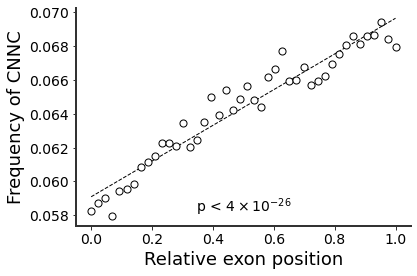

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X[:, 1], Y, facecolor='w', s=50, linewidth=1, zorder=2)
ax.plot(X[:, 1], Y_hat, zorder=1, linewidth=1, linestyle='--', color='k')
ax.set_xlabel('Relative exon position')
ax.set_ylabel('Frequency of CNNC')
ax.text(0.5, 0.0585, 'p < $4\\times10^{-26}$', fontweight='normal', ha='center', va='center')

fig.savefig('./figs/CNNC_genome_position_dependence.svg',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/CNNC_genome_position_dependence.pdf',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')

# Figure 4b: depletion of secondary structure in genome

In [7]:
hypothesis_test_data = load('../2022_01_16_secondary_structure_depletion_genome/data/secondary_structure_plot_data.pkl')

null_distribution_distributions = [np.concatenate(
    list(e.values())) for e in tqdm(hypothesis_test_data['null_distributions'])]
null_top_deciles = [np.quantile(e, q=0.9)
                    for e in null_distribution_distributions]

test_stat = np.quantile(np.concatenate(list(hypothesis_test_data['genome_acts_by_size'].values())), q=0.9)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [8]:
np.mean([test_stat>e for e in null_top_deciles])

1.0

In [9]:
test_stat

0.26613662242889397

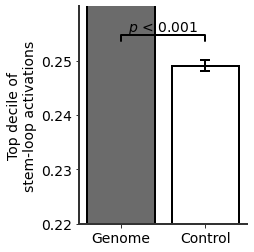

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
ax.bar([1], np.mean(null_top_deciles), yerr=np.std(null_top_deciles), error_kw=dict(
    lw=2, capsize=5, capthick=2), color='w', edgecolor='k', linewidth=2)
ax.bar([0], [test_stat], color='#6b6b6b', edgecolor='k', linewidth=2)
ax.set_ylim(0.22, 0.26)
ax.set_ylabel('Top decile of\nstem-loop activations', fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Genome', 'Control'])

props = {'connectionstyle':'bar','arrowstyle':'-',\
                 'shrinkA':20,'shrinkB':20,'linewidth':2}
ax.annotate('$p$ < 0.001', xy=(0.5, 0.256), zorder=10, ha='center', va='center')
ax.annotate('', xy=(0,0.25), xytext=(1, 0.25), arrowprops=props)

ax.set_yticks([0.22, 0.23, 0.24, 0.25])

fig.savefig('./figs/stem_loop_genome_validation.svg',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/stem_loop_genome_validation.pdf',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')

# Figure 4?: depletion of Porg in genome

In [46]:
hypothesis_test_data = load('../2022_01_15_borg_depletion_genome/data/porg_plot_data.pkl')

null_distribution_distributions = [np.concatenate(
    list(e.values())) for e in tqdm(hypothesis_test_data['null_distributions'])]
null_top_deciles = [np.quantile(e, q=0.9)
                    for e in null_distribution_distributions]

test_stat = np.quantile(np.concatenate(list(hypothesis_test_data['genome_acts_by_size'].values())), q=0.9)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
ax.bar([1], np.mean(null_top_deciles), yerr=np.std(null_top_deciles), error_kw=dict(
    lw=2, capsize=5, capthick=2), color='w', edgecolor='k', linewidth=2)
ax.bar([0], [test_stat], color='#6b6b6b', edgecolor='k', linewidth=2)
ax.set_ylim(0.14, 0.146)
ax.set_ylabel('Top decile of\nPorg activations', fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Genome', 'Control'])

props = {'connectionstyle':'bar','arrowstyle':'-',\
                 'shrinkA':20,'shrinkB':20,'linewidth':2}
ax.annotate('p = 0.018', xy=(0.5, 0.1454), zorder=10, ha='center', va='center')
ax.annotate('', xy=(0,0.1445), xytext=(1, 0.1445), arrowprops=props)

fig.savefig('./figs/porg_genome_validation.svg',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')
fig.savefig('./figs/porg_genome_validation.pdf',
            transparent=True, pad_inches=0.1,
    bbox_inches='tight')

In [23]:
np.mean([test_stat > e for e in null_top_deciles])

0.018